# Sarcasm Detection in News Headlines

## Goal

This notebook builds a supervised NLP model that predicts whether a news headline is sarcastic or non-sarcastic.

## Main techniques

- text classification
- TF-IDF vectorisation
- word n-grams
- character n-grams
- logistic regression
- linear support vector machine
- confusion matrix analysis
- misclassification analysis
- model coefficient interpretation

## Main question

Does combining word and character features improve sarcasm detection compared with word features alone?

In [1]:
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
dataset_path = kagglehub.dataset_download(
    "rmisra/news-headlines-dataset-for-sarcasm-detection"
)

dataset_path = Path(dataset_path)

print("Dataset downloaded to:", dataset_path)

json_files = list(dataset_path.rglob("*.json"))

for file in json_files:
    print(file.name, file.stat().st_size)

100%|██████████| 3.30M/3.30M [00:01<00:00, 2.09MB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\rmisra\news-headlines-dataset-for-sarcasm-detection\versions\2
Sarcasm_Headlines_Dataset.json 5616830
Sarcasm_Headlines_Dataset_v2.json 6057046


In [3]:
if not json_files:
    raise FileNotFoundError("No JSON files were found.")

json_path = max(
    json_files,
    key=lambda file: file.stat().st_size
)

print("Selected file:", json_path.name)

Selected file: Sarcasm_Headlines_Dataset_v2.json


In [4]:
try:
    df = pd.read_json(json_path, lines=True)
except ValueError:
    df = pd.read_json(json_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (28619, 3)


,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   is_sarcastic  28619 non-null  int64
 1   headline      28619 non-null  str  
 2   article_link  28619 non-null  str  
dtypes: int64(1), str(2)
memory usage: 4.9 MB


In [6]:
df["is_sarcastic"].value_counts()

is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

In [7]:
df = df[
    ["headline", "is_sarcastic"]
].copy()

df["headline"] = (
    df["headline"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df = df[df["headline"].str.len() > 0]

duplicate_count = df.duplicated(
    subset=["headline"]
).sum()

print("Duplicate headlines:", duplicate_count)

df = (
    df.drop_duplicates(subset=["headline"])
    .reset_index(drop=True)
)

print("Cleaned shape:", df.shape)

Duplicate headlines: 116
Cleaned shape: (28503, 2)


## Data loading 

The selected dataset file initially contained 28,619 headlines and three columns:

- headline
- is_sarcastic
- article_link

There were no missing values.

After keeping only the headline and target columns, cleaning whitespace, and removing 116 duplicate headlines, 28,503 unique headlines remained.

The cleaned class distribution was:

- Non-sarcastic: 14,951 headlines
- Sarcastic: 13,552 headlines

The dataset is therefore moderately balanced, with sarcastic headlines making up approximately 47.55% of the data.

In [8]:
df["character_count"] = df["headline"].str.len()
df["word_count"] = df["headline"].str.split().apply(len)

df[
    ["character_count", "word_count"]
].describe()

,character_count,word_count
count,28503.000000,28503.000000
mean,62.377855,10.060871
std,20.704686,3.385275
min,7.000000,2.000000
25%,49.000000,8.000000
50%,62.000000,10.000000
75%,75.000000,12.000000
max,926.000000,151.000000


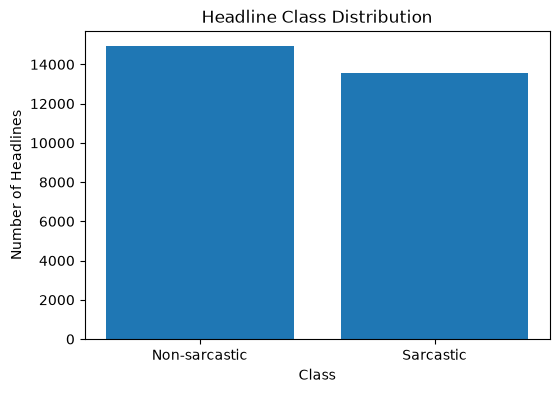

In [9]:
class_counts = df["is_sarcastic"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Non-sarcastic", "Sarcastic"],
    class_counts.values
)
plt.title("Headline Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Headlines")
plt.show()

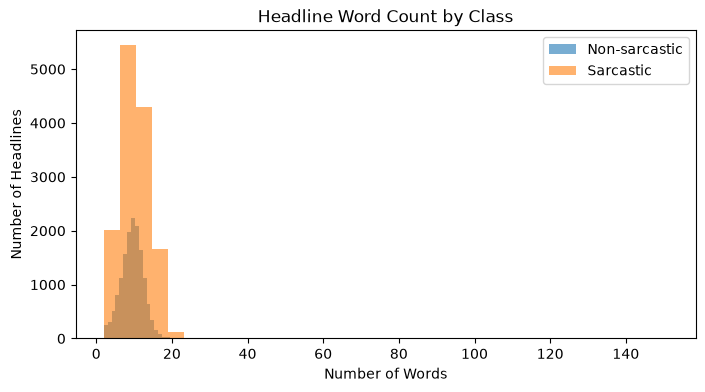

In [10]:
plt.figure(figsize=(8, 4))

plt.hist(
    df.loc[df["is_sarcastic"] == 0, "word_count"],
    bins=35,
    alpha=0.6,
    label="Non-sarcastic"
)

plt.hist(
    df.loc[df["is_sarcastic"] == 1, "word_count"],
    bins=35,
    alpha=0.6,
    label="Sarcastic"
)

plt.title("Headline Word Count by Class")
plt.xlabel("Number of Words")
plt.ylabel("Number of Headlines")
plt.legend()
plt.show()

In [11]:
print("Example non-sarcastic headlines:\n")

for headline in df[df["is_sarcastic"] == 0]["headline"].sample(
    5,
    random_state=RANDOM_STATE
):
    print("-", headline)

print("\nExample sarcastic headlines:\n")

for headline in df[df["is_sarcastic"] == 1]["headline"].sample(
    5,
    random_state=RANDOM_STATE
):
    print("-", headline)

Example non-sarcastic headlines:

- 'california country' singer turns ballad into heartbreaking plea for queer inclusion
- report: trump bans 'transgender,' 'fetus,' 'science-based' from cdc documents
- test-driven teacher evaluations strike out
- john mccain, czar hater, calls for ebola czar
- channing tatum and jenna dewan tatum slay on the golden globes red carpet

Example sarcastic headlines:

- panicking mitch mcconnell shoves entire senate healthcare bill into mouth as democrat walks past
- tear gas manufacturers worried about association with everything tear gas used for
- report: middle east quickly running out of land area for violence to spill over to
- bush seeking non-masturbating surgeon general
- thursday cry moved up to wednesday due to scheduling conflict


## Text exploration 

Headlines contained an average of approximately 10 words and 62 characters.

Most headlines were relatively short, although the longest headline contained 151 words and 926 characters.

The word-count distributions of sarcastic and non-sarcastic headlines overlapped heavily. This shows that headline length alone is not enough to identify sarcasm.

The sampled sarcastic headlines often used exaggeration, unexpected situations, or deliberately absurd phrasing. However, some genuine headlines also sounded unusual, making the classification task challenging.

In [12]:
X = df["headline"]
y = df["is_sarcastic"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("Training headlines:", len(X_train))
print("Validation headlines:", len(X_val))
print("Test headlines:", len(X_test))

print("\nSarcastic rates:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Training headlines: 17101
Validation headlines: 5701
Test headlines: 5701

Sarcastic rates:
Train: 0.47546927080287704
Validation: 0.47535520084195754
Test: 0.47553060866514646


## Data split 

A stratified split was used to preserve the sarcastic headline rate across all datasets.

The resulting split was:

- Training set: 17,101 headlines
- Validation set: 5,701 headlines
- Test set: 5,701 headlines

The sarcastic rates were:

- Training: 47.55%
- Validation: 47.54%
- Test: 47.55%

The validation set was used for model selection, while the test set remained untouched until the final model was chosen.

In [13]:
def get_model_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]

    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)

    return None

In [14]:
def evaluate_text_model(
    model,
    X_data,
    y_true,
    model_name
):
    y_pred = model.predict(X_data)
    y_score = get_model_scores(model, X_data)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

    if y_score is not None:
        result["roc_auc"] = roc_auc_score(
            y_true,
            y_score
        )

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    for metric, value in result.items():
        if metric != "model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Non-sarcastic",
                "Sarcastic"
            ],
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Non-sarcastic",
            "Sarcastic"
        ]
    )

    display.plot()
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

    return result, y_pred, y_score

Dummy Baseline
accuracy: 0.5246
balanced_accuracy: 0.5000
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.5000

Classification Report:
               precision    recall  f1-score   support

Non-sarcastic       0.52      1.00      0.69      2991
    Sarcastic       0.00      0.00      0.00      2710

     accuracy                           0.52      5701
    macro avg       0.26      0.50      0.34      5701
 weighted avg       0.28      0.52      0.36      5701



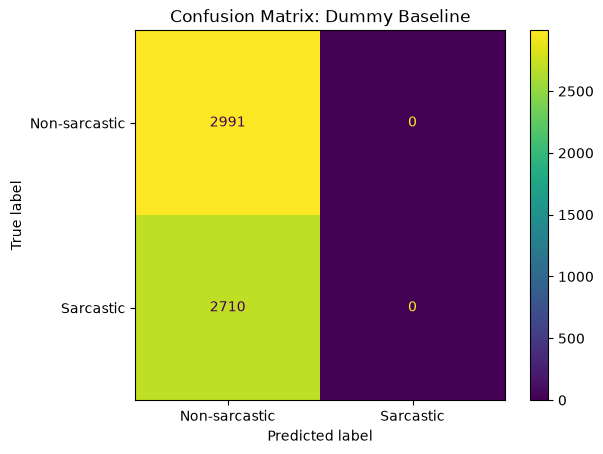

In [15]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(max_features=1000)
    ),
    (
        "model",
        DummyClassifier(strategy="most_frequent")
    )
])

baseline_model.fit(X_train, y_train)

baseline_result, _, _ = evaluate_text_model(
    model=baseline_model,
    X_data=X_val,
    y_true=y_val,
    model_name="Dummy Baseline"
)

## Baseline 

The dummy baseline predicted every headline as non-sarcastic.

It achieved:

- Accuracy: 0.5246
- Balanced accuracy: 0.5000
- Precision: 0.0000
- Recall: 0.0000
- F1-score: 0.0000
- ROC-AUC: 0.5000

Although the baseline achieved approximately 52% accuracy because non-sarcastic headlines were slightly more common, it failed to detect any sarcastic headlines.

This demonstrates why accuracy alone is not enough to evaluate the classifier.

Word TF-IDF + Logistic Regression
accuracy: 0.7878
balanced_accuracy: 0.7872
precision: 0.7768
recall: 0.7768
f1: 0.7768
roc_auc: 0.8710

Classification Report:
               precision    recall  f1-score   support

Non-sarcastic       0.80      0.80      0.80      2991
    Sarcastic       0.78      0.78      0.78      2710

     accuracy                           0.79      5701
    macro avg       0.79      0.79      0.79      5701
 weighted avg       0.79      0.79      0.79      5701



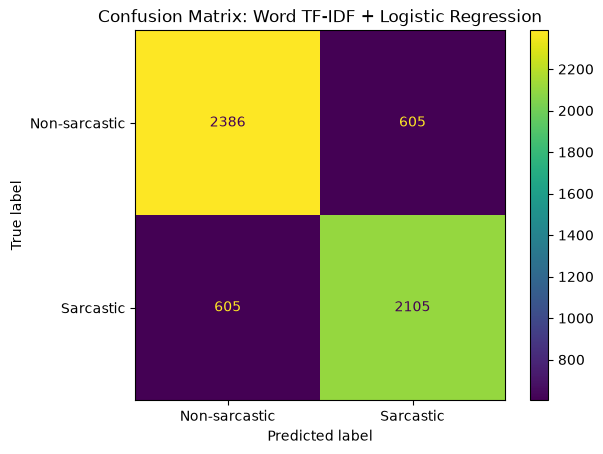

In [16]:
word_logistic_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            max_features=30000,
            sublinear_tf=True
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

word_logistic_model.fit(X_train, y_train)

logistic_result, logistic_val_preds, logistic_val_scores = (
    evaluate_text_model(
        model=word_logistic_model,
        X_data=X_val,
        y_true=y_val,
        model_name="Word TF-IDF + Logistic Regression"
    )
)

## Word model 

The Word TF-IDF + Logistic Regression model achieved:

- Accuracy: 0.7878
- Balanced accuracy: 0.7872
- Precision: 0.7768
- Recall: 0.7768
- F1-score: 0.7768
- ROC-AUC: 0.8710

This was a strong improvement over the dummy baseline.

The result shows that individual words and two-word phrases contain useful signals for sarcasm detection. However, word features alone could not fully capture stylistic patterns such as unusual spelling fragments, punctuation structure, or word endings.

Word + Character TF-IDF with Linear SVM
accuracy: 0.8479
balanced_accuracy: 0.8480
precision: 0.8335
recall: 0.8498
f1: 0.8416
roc_auc: 0.9270

Classification Report:
               precision    recall  f1-score   support

Non-sarcastic       0.86      0.85      0.85      2991
    Sarcastic       0.83      0.85      0.84      2710

     accuracy                           0.85      5701
    macro avg       0.85      0.85      0.85      5701
 weighted avg       0.85      0.85      0.85      5701



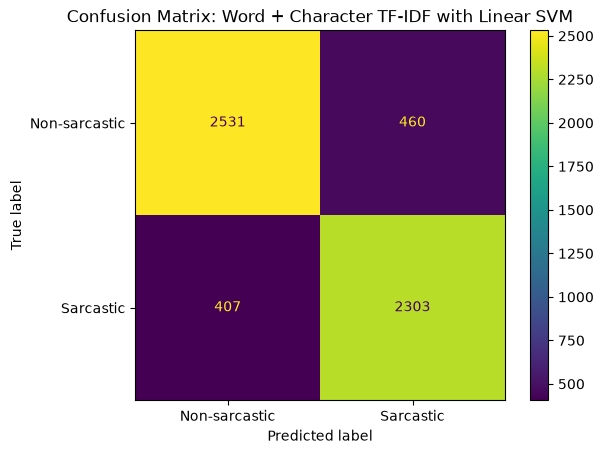

In [17]:
word_char_svm_model = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word",
                TfidfVectorizer(
                    lowercase=True,
                    stop_words="english",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                    max_features=25000,
                    sublinear_tf=True
                )
            ),
            (
                "char",
                TfidfVectorizer(
                    analyzer="char_wb",
                    lowercase=True,
                    ngram_range=(3, 5),
                    min_df=3,
                    max_features=25000,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "model",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

word_char_svm_model.fit(X_train, y_train)

svm_result, svm_val_preds, svm_val_scores = (
    evaluate_text_model(
        model=word_char_svm_model,
        X_data=X_val,
        y_true=y_val,
        model_name="Word + Character TF-IDF with Linear SVM"
    )
)

## Word and character model 

The combined Word + Character TF-IDF with Linear SVM model achieved:

- Accuracy: 0.8479
- Balanced accuracy: 0.8480
- Precision: 0.8335
- Recall: 0.8498
- F1-score: 0.8416
- ROC-AUC: 0.9270

This model substantially outperformed the word-only logistic regression model.

Character n-grams added useful information about smaller writing patterns, word fragments, and stylistic structure that were not captured by normal word tokenisation.

In [18]:
results_df = pd.DataFrame([
    baseline_result,
    logistic_result,
    svm_result
])

results_df.sort_values(
    "f1",
    ascending=False
)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
2,Word + Character TF-IDF with Linear SVM,0.847921,0.84801,0.833514,0.849815,0.841586,0.926974
1,Word TF-IDF + Logistic Regression,0.787757,0.78724,0.776753,0.776753,0.776753,0.870966
0,Dummy Baseline,0.524645,0.50000,0.000000,0.000000,0.000000,0.500000


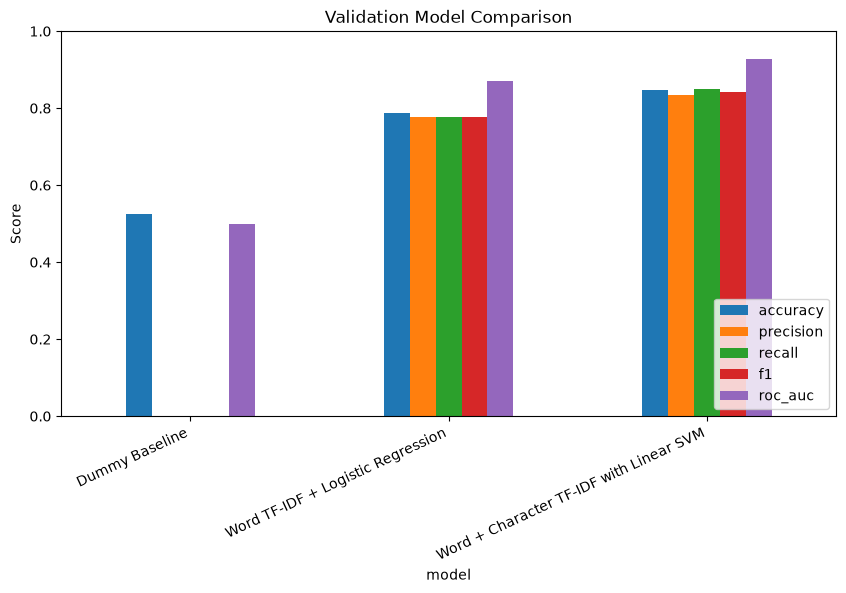

In [19]:
comparison_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

plot_df = results_df.set_index(
    "model"
)[comparison_metrics]

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Validation Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.show()

## Model comparison 

The best validation model was Word + Character TF-IDF with Linear SVM.

Validation results:

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Word + Character TF-IDF with Linear SVM | 0.8479 | 0.8335 | 0.8498 | 0.8416 | 0.9270 |
| Word TF-IDF + Logistic Regression | 0.7878 | 0.7768 | 0.7768 | 0.7768 | 0.8710 |
| Dummy Baseline | 0.5246 | 0.0000 | 0.0000 | 0.0000 | 0.5000 |

Adding character features improved validation F1-score by approximately 0.0648 and accuracy by approximately 0.0602 compared with the word-only model.

This suggests that sarcasm detection benefits from combining headline vocabulary with character-level writing patterns.

In [20]:
model_lookup = {
    "Word TF-IDF + Logistic Regression":
        word_logistic_model,

    "Word + Character TF-IDF with Linear SVM":
        word_char_svm_model
}

best_model_name = (
    results_df[
        results_df["model"] != "Dummy Baseline"
    ]
    .sort_values("f1", ascending=False)
    .iloc[0]["model"]
)

best_model = model_lookup[best_model_name]

print("Best validation model:", best_model_name)

Best validation model: Word + Character TF-IDF with Linear SVM


Word + Character TF-IDF with Linear SVM, Test Set
accuracy: 0.8548
balanced_accuracy: 0.8547
precision: 0.8432
recall: 0.8532
f1: 0.8482
roc_auc: 0.9302

Classification Report:
               precision    recall  f1-score   support

Non-sarcastic       0.87      0.86      0.86      2990
    Sarcastic       0.84      0.85      0.85      2711

     accuracy                           0.85      5701
    macro avg       0.85      0.85      0.85      5701
 weighted avg       0.85      0.85      0.85      5701



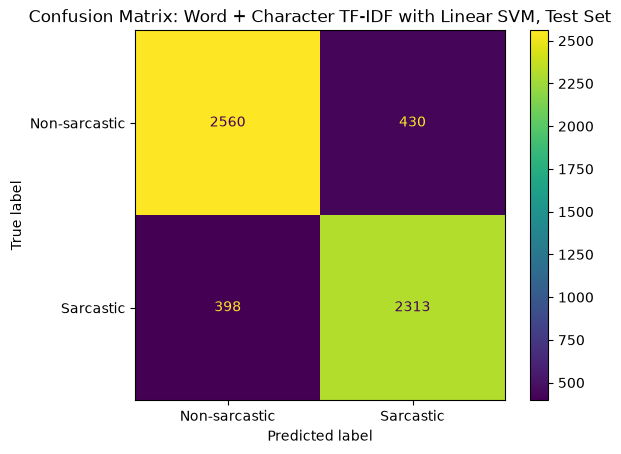

In [21]:
test_result, test_preds, test_scores = (
    evaluate_text_model(
        model=best_model,
        X_data=X_test,
        y_true=y_test,
        model_name=f"{best_model_name}, Test Set"
    )
)

## Final test result 

The selected Word + Character TF-IDF with Linear SVM model achieved:

- Accuracy: 0.8548
- Balanced accuracy: 0.8547
- Precision: 0.8432
- Recall: 0.8532
- F1-score: 0.8482
- ROC-AUC: 0.9302

The confusion matrix contained:

- 2,560 correctly classified non-sarcastic headlines
- 2,313 correctly classified sarcastic headlines
- 430 false positives
- 398 false negatives

Test performance was slightly higher than validation performance. The test F1-score increased from 0.8416 to 0.8482, suggesting that the model generalised consistently to unseen headlines.

In [22]:
error_df = pd.DataFrame({
    "headline": X_test,
    "true_label": y_test,
    "predicted_label": test_preds,
    "model_score": test_scores
})

error_df["correct"] = (
    error_df["true_label"]
    == error_df["predicted_label"]
)

print("Total errors:", (~error_df["correct"]).sum())
print("Error rate:", (~error_df["correct"]).mean())

Total errors: 828
Error rate: 0.14523767760042097


In [23]:
false_positives = (
    error_df[
        (error_df["true_label"] == 0)
        & (error_df["predicted_label"] == 1)
    ]
    .sort_values(
        "model_score",
        ascending=False
    )
)

false_positives[
    ["headline", "model_score"]
].head(15)

,headline,model_score
20214,actor nils hognestad performs in front of a li...,1.693188
21250,scientists discover tiniest hedgehog ever,1.576024
28202,rinkins report: keys to building valuable busi...,1.570020
20817,nestle to switch to cage-free eggs in u.s. by ...,1.513221
26533,greyhound doesn't know if its own bus drivers ...,1.507107
11284,shameless new dad uses craigslist to try to ho...,1.496799
18562,epa accidentally spills millions of gallons of...,1.474331
12561,full-circle friendship rooted in triple negati...,1.441363
18457,man missing after explosion was saving up to r...,1.435892
8182,sandy hook father to alex jones: 'i'm not back...,1.403424


In [24]:
false_negatives = (
    error_df[
        (error_df["true_label"] == 1)
        & (error_df["predicted_label"] == 0)
    ]
    .sort_values(
        "model_score",
        ascending=True
    )
)

false_negatives[
    ["headline", "model_score"]
].head(15)

,headline,model_score
27715,trump retweets video from anti-muslim hate group,-2.441706
5643,'secretary clinton is a different person than ...,-2.155673
6308,christianity: is your family at risk?,-2.001634
5339,comey warns democrats that having leftist poli...,-1.682840
25218,obama turns 50 despite republican opposition,-1.640408
4517,u.s. to arab world: 'stop hating us or suffer ...,-1.604487
17042,boilermakers protest purdue's mascot,-1.588181
8484,hippie will tell you what the real crime is,-1.580039
22526,"'you are donald trump, 45th president of the u...",-1.525536
6102,naacp calls for more diversity in police lineups,-1.505552


## Error analysis 

The final model made 828 errors from 5,701 test headlines, giving an error rate of approximately 14.52%.

The errors included:

- 430 false positives: genuine headlines predicted as sarcastic
- 398 false negatives: sarcastic headlines predicted as genuine

False positives were slightly more common.

Many false positives described unusual or dramatic real events, causing them to resemble exaggerated sarcastic writing.

Some false negatives used relatively normal journalistic language or depended on political, cultural, or background knowledge. Without this context, the model interpreted them as genuine headlines.

This confirms that sarcasm cannot always be identified from headline text alone.

In [25]:
feature_names = (
    word_char_svm_model
    .named_steps["features"]
    .get_feature_names_out()
)

coefficients = (
    word_char_svm_model
    .named_steps["model"]
    .coef_[0]
)

feature_names = np.asarray(feature_names)

word_mask = np.array([
    feature.startswith("word__")
    for feature in feature_names
])

word_feature_names = np.array([
    feature.replace("word__", "")
    for feature in feature_names[word_mask]
])

word_coefficients = coefficients[word_mask]

In [26]:
top_sarcastic_indices = np.argsort(
    word_coefficients
)[-20:][::-1]

top_non_sarcastic_indices = np.argsort(
    word_coefficients
)[:20]

sarcastic_terms_df = pd.DataFrame({
    "term": word_feature_names[
        top_sarcastic_indices
    ],
    "coefficient": word_coefficients[
        top_sarcastic_indices
    ]
})

non_sarcastic_terms_df = pd.DataFrame({
    "term": word_feature_names[
        top_non_sarcastic_indices
    ],
    "coefficient": word_coefficients[
        top_non_sarcastic_indices
    ]
})

print("Strongest sarcastic indicators:")
display(sarcastic_terms_df)

print("\nStrongest non-sarcastic indicators:")
display(non_sarcastic_terms_df)

Strongest sarcastic indicators:


,term,coefficient
0,nation,2.596704
1,area,2.426726
2,guy,1.624936
3,onion,1.599983
4,man,1.576083
5,report,1.464363
6,wondering,1.433550
7,shit,1.378686
8,news reporter,1.375469
9,character,1.316142



Strongest non-sarcastic indicators:


,term,coefficient
0,trans,-1.277447
1,tied,-1.258289
2,truck,-1.252894
3,george bush,-1.244250
4,gop congressman,-1.243792
5,congo,-1.207546
6,ebola,-1.200227
7,havana,-1.186328
8,clippers,-1.184178
9,donald trump,-1.180824


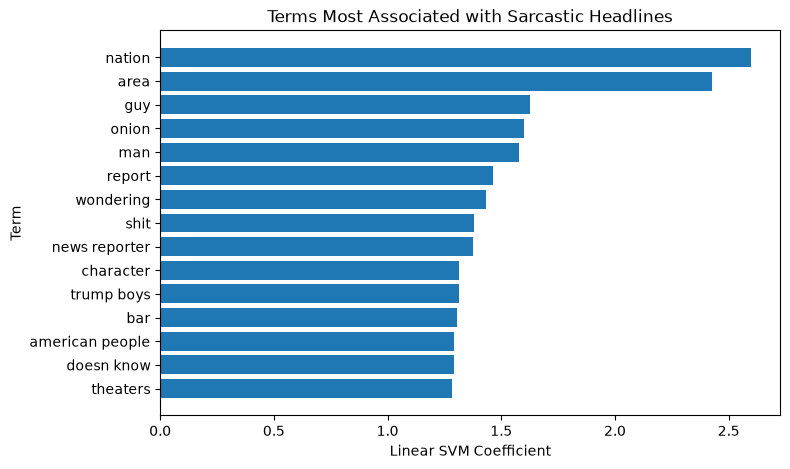

In [27]:
plt.figure(figsize=(8, 5))

plt.barh(
    sarcastic_terms_df["term"].head(15)[::-1],
    sarcastic_terms_df["coefficient"].head(15)[::-1]
)

plt.title("Terms Most Associated with Sarcastic Headlines")
plt.xlabel("Linear SVM Coefficient")
plt.ylabel("Term")
plt.show()

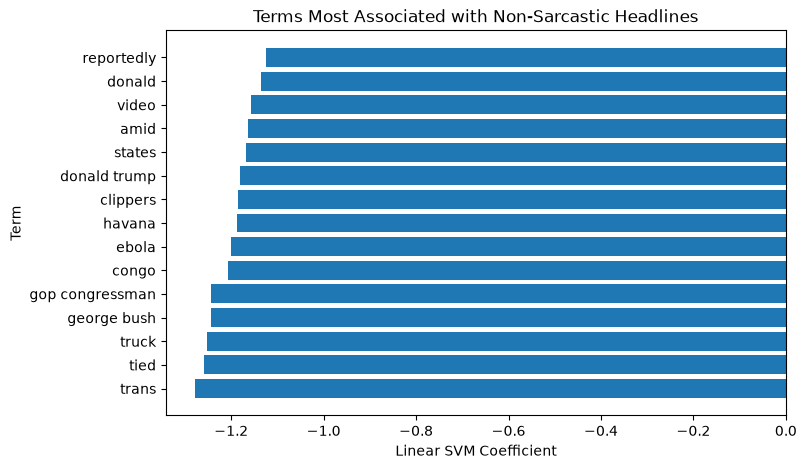

In [28]:
plt.figure(figsize=(8, 5))

non_sarcastic_plot = (
    non_sarcastic_terms_df
    .head(15)
    .sort_values("coefficient")
)

plt.barh(
    non_sarcastic_plot["term"],
    non_sarcastic_plot["coefficient"]
)

plt.title("Terms Most Associated with Non-Sarcastic Headlines")
plt.xlabel("Linear SVM Coefficient")
plt.ylabel("Term")
plt.show()

## Influential terms note

The word features most strongly associated with sarcastic headlines included:

- nation
- area
- guy
- onion
- man
- report
- wondering
- shit
- news reporter
- character
- local
- authorities

The strongest non-sarcastic indicators included:

- trans
- tied
- truck
- George Bush
- GOP congressman
- Congo
- Ebola
- Havana
- Donald Trump
- reportedly
- video

Terms such as `nation`, `area`, `man`, `report`, and `local` may reflect repeated satirical headline templates.

However, these coefficients should not be interpreted as universal sarcasm rules. They represent statistical patterns in this particular dataset and may partly capture differences between publication sources and writing styles.

In [29]:
def predict_sarcasm(headlines, model=best_model):
    predictions = model.predict(headlines)
    scores = get_model_scores(model, headlines)

    results = pd.DataFrame({
        "headline": headlines,
        "prediction": np.where(
            predictions == 1,
            "Sarcastic",
            "Non-sarcastic"
        )
    })

    if scores is not None:
        results["model_score"] = scores

    return results

In [30]:
example_headlines = [
    "Local man thrilled to receive another password reset email",
    "Scientists announce successful launch of new satellite",
    "Nation celebrates completing one entire productive meeting",
    "Government releases updated economic growth figures"
]

predict_sarcasm(example_headlines)

,headline,prediction,model_score
0,Local man thrilled to receive another password...,Sarcastic,1.956886
1,Scientists announce successful launch of new s...,Sarcastic,1.973370
2,Nation celebrates completing one entire produc...,Sarcastic,1.771572
3,Government releases updated economic growth fi...,Sarcastic,1.247066


## Custom predictions 

The model classified all four custom example headlines as sarcastic, including the two deliberately factual examples:

- Scientists announce successful launch of new satellite
- Government releases updated economic growth figures

This shows that the model can overpredict sarcasm for short, formal headline-style sentences.

The returned Linear SVM scores are decision margins rather than calibrated probabilities. A positive score indicates that the headline falls on the sarcastic side of the decision boundary, but the value should not be interpreted directly as a percentage probability.

The custom results reinforce the limitation that the model may rely partly on vocabulary and publication style rather than understanding sarcasm in a human-like way.